<a href="https://colab.research.google.com/github/pauloricardo2-alt/lia1_2026_1/blob/main/Atividade_Aula_8_9_Boston_Housing_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Construir um modelo de Inteligência Artificial capaz de prever o valor  uma casa da cidade de Boston, de acordo com as  características: ['Crime', 'Zona', 'Indústria', 'Rio(0/1)', 'NOX', 'Quartos', 'Idade', 'Distância', 'Rodovias', 'Imposto', 'Aluno/Prof, B, StatusSocial].
 Dada um novo valor   de uma dessas categorias o modelo deve ser capaz de prever o valor da casa.



In [ ]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [ ]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow


In [ ]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Carregar o dataset Boston Housing
(train_data, train_targets), (test_data, test_targets) = tf.keras.datasets.boston_housing.load_data()

print(f"Formato dos dados de treino: {train_data.shape}")

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Formato dos dados de treino: (404, 13)


## Carregando os dados - matéria prima
https://keras.io/2/api/datasets/boston_housing/

In [ ]:
# Normalização (Subtrai a média e divide pelo desvio padrão)
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std

test_data -= mean
test_data /= std

print("Dados normalizados com sucesso!")

Dados normalizados com sucesso!


## Construção do Modelo


In [ ]:
def construir_modelo():
    modelo = models.Sequential([
        # Entrada: 13 variáveis (features)
        layers.Input(shape=(13,)),

        # Camadas Escondidas (Hidden Layers)
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),

        # Camada de Saída: 1 único neurônio (o preço)
        # Sem ativação (linear), pois queremos um valor real livre
        layers.Dense(1)
    ])

    # Compilação: Usamos 'mse' (Erro Quadrático Médio) e 'mae' (Erro Médio Absoluto)
    modelo.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return modelo

modelo_boston = construir_modelo()

In [ ]:
#Vamo ver se a nossa aquitetura ta ok

In [ ]:
# Sumário do modelo
modelo_boston.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelo_boston.compile(
    optimizer='rmsprop',           # Algoritmo de ajuste dos pesos (similar ao adam)
    loss='mse',                    # Mean Squared Error: foca em reduzir erros grandes
    metrics=['mae']                # Mean Absolute Error: erro médio em "milhares de dólares"
)

In [ ]:
#Quanto mais ele roda, mais aprende, mais tem um momento em que ele começa a desaprender
#Ele desaprende por que pode começar a viciar e a tender
#Pode ser que o dataset seja desbalanceado, tipo 1000 de
#Overfit
%%time
# Treinando o modelo
history = modelo_boston.fit(train_data, train_targets,
                           epochs=200,
                           batch_size=16,
                           validation_split=0.2,
                           verbose=1)


Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.5447 - mae: 1.5647 - val_loss: 14.9259 - val_mae: 2.4833
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.5659 - mae: 1.5565 - val_loss: 16.3143 - val_mae: 2.7329
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.3683 - mae: 1.5868 - val_loss: 13.8926 - val_mae: 2.5208
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.4018 - mae: 1.5671 - val_loss: 15.1638 - val_mae: 2.5810
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.6276 - mae: 1.6225 - val_loss: 14.1085 - val_mae: 2.5108
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.1786 - mae: 1.5451 - val_loss: 15.8660 - val_mae: 2.6736
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.3906 - mae: 1.5769 - val_loss: 14.6754 - val_mae: 2.6712
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.3596 - mae: 1.5588 - val_loss: 16.2342 - val_mae: 2.6536
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - lo

## Avaliação do modelo

In [ ]:
# Avalia o modelo usando o conjunto de teste numérico
# O evaluate vai retornar o MSE (Erro Quadrático) e o MAE (Erro Médio Absoluto)
mse_teste, mae_teste = modelo_boston.evaluate(test_data, test_targets, verbose=2)

# No Boston Housing, o MAE representa o erro em "milhares de dólares"
print(f'\nErro Médio Absoluto (MAE): ${mae_teste * 1000:.2f}')

4/4 - 0s - 12ms/step - loss: 15.0748 - mae: 2.6336

Erro Médio Absoluto (MAE): $2633.55


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


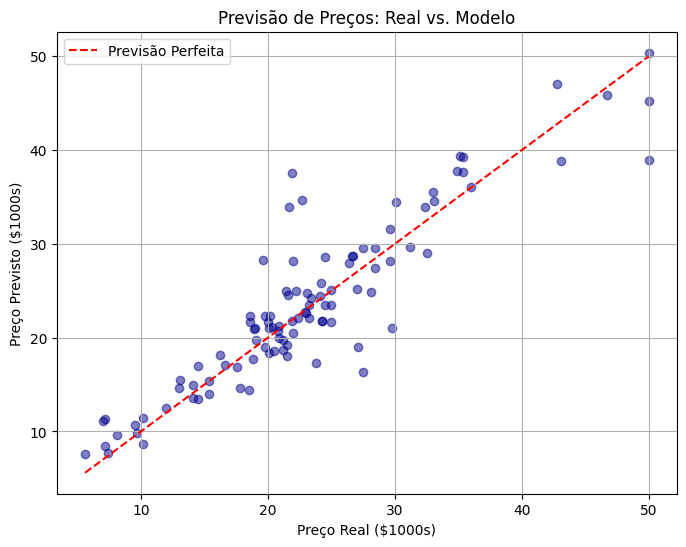

In [ ]:
# --- Equivalente à Matriz de Confusão (Validação de Regressão) ---

# 1. Fazer as previsões nos dados de teste
previsoes = modelo_boston.predict(test_data)

# 2. Criar o gráfico de comparação
plt.figure(figsize=(8, 6))
plt.scatter(test_targets, previsoes, alpha=0.5, color='darkblue')

# Linha de perfeição: se a IA acertasse tudo, todos os pontos estariam aqui
plt.plot([min(test_targets), max(test_targets)],
         [min(test_targets), max(test_targets)],
         color='red', linestyle='--', label='Previsão Perfeita')

plt.title('Previsão de Preços: Real vs. Modelo')
plt.xlabel('Preço Real ($1000s)')
plt.ylabel('Preço Previsto ($1000s)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- Célula de Interação: Prevendo o preço de uma casa nova ---

# 1. Defina as 13 características da casa (Exemplo hipotético)
# Ordem: Crime, Zona, Indústria, Rio(0/1), NOX, Quartos, Idade, Distância, Rodovias, Imposto, Aluno/Prof, B, StatusSocial
minha_casa = np.array([[0.006, 18.0, 2.31, 0, 0.538, 6.57, 65.2, 4.09, 1, 296.0, 15.3, 396.9, 4.98]])

# 2. IMPORTANTE: Você precisa normalizar esses números
# usando a mesma média e desvio padrão que usamos no treino!
minha_casa_norm = (minha_casa - mean) / std

# 3. Peça para a IA "chutar" o preço
previsao = modelo_boston.predict(minha_casa_norm)

print(f"O preço previsto para esta casa é: ${previsao[0][0] * 1000:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
O preço previsto para esta casa é: $12975.58
